# 🏆 Predicción: España vs Austria - Mundial 2026
### 1/16 de final - 2 julio | SoFi Stadium, Los Ángeles 🇺🇸

Modelo basado en **+47,000 partidos internacionales históricos** (1872-2025).  
**Poisson** + **Monte Carlo** con parámetros derivados 100% de datos reales.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
np.random.seed(42)

## 📥 Carga de datos: +47,000 partidos internacionales

In [2]:
url = 'https://raw.githubusercontent.com/martj42/international_results/master/results.csv'
df = pd.read_csv(url)
df['date'] = pd.to_datetime(df['date'])

# Eliminar partidos sin resultado (programados pero no jugados)
df = df.dropna(subset=['home_score', 'away_score'])

print(f'📊 Dataset cargado: {len(df):,} partidos')
print(f'📅 Desde {df["date"].min().strftime("%Y")} hasta {df["date"].max().strftime("%Y")}')
print(f'🏟️  Torneos: {df["tournament"].nunique()}')
df.head()

📊 Dataset cargado: 49,487 partidos
📅 Desde 1872 hasta 2026
🏟️  Torneos: 200


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


## 🇪🇸🇦🇹 Head-to-Head histórico

In [3]:
team_a = 'Spain'
team_b = 'Austria'

h2h = df[((df['home_team'] == team_a) & (df['away_team'] == team_b)) |
          ((df['home_team'] == team_b) & (df['away_team'] == team_a))].copy()

h2h['spain_goals']  = np.where(h2h['home_team'] == team_a, h2h['home_score'], h2h['away_score'])
h2h['austria_goals'] = np.where(h2h['home_team'] == team_b, h2h['home_score'], h2h['away_score'])
h2h['result'] = np.where(h2h['spain_goals'] > h2h['austria_goals'], 'España',
                 np.where(h2h['spain_goals'] < h2h['austria_goals'], 'Austria', 'Empate'))

print(f'⚔️  HISTORIAL DIRECTO: {len(h2h)} partidos')
print('=' * 50)
print(h2h['result'].value_counts().to_string())
print(f'\n⚽ Media goles España:  {h2h["spain_goals"].mean():.2f}')
print(f'⚽ Media goles Austria: {h2h["austria_goals"].mean():.2f}')
print()
print(h2h[['date', 'home_team', 'home_score', 'away_score', 'away_team', 'tournament']].tail(10).to_string(index=False))

⚔️  HISTORIAL DIRECTO: 16 partidos
result
España     9
Austria    4
Empate     3

⚽ Media goles España:  2.69
⚽ Media goles Austria: 1.38

      date home_team  home_score  away_score away_team                   tournament
1981-09-23   Austria         0.0         0.0     Spain                     Friendly
1985-11-20     Spain         0.0         0.0   Austria                     Friendly
1987-04-01   Austria         2.0         3.0     Spain      UEFA Euro qualification
1987-10-14     Spain         2.0         0.0   Austria      UEFA Euro qualification
1990-03-28     Spain         2.0         3.0   Austria                     Friendly
1999-03-27     Spain         9.0         0.0   Austria      UEFA Euro qualification
1999-09-04   Austria         1.0         3.0     Spain      UEFA Euro qualification
2000-10-11   Austria         1.0         1.0     Spain FIFA World Cup qualification
2001-09-01     Spain         4.0         0.0   Austria FIFA World Cup qualification
2009-11-18   Austria 

## 📈 Forma reciente (últimos 20 partidos)

In [4]:
def get_team_stats(df, team, n_matches=20):
    team_matches = df[(df['home_team'] == team) | (df['away_team'] == team)].copy()
    team_matches = team_matches.sort_values('date').tail(n_matches)

    goals_scored   = np.where(team_matches['home_team'] == team,
                               team_matches['home_score'], team_matches['away_score'])
    goals_conceded = np.where(team_matches['home_team'] == team,
                               team_matches['away_score'], team_matches['home_score'])

    wins   = int(np.sum(goals_scored > goals_conceded))
    draws  = int(np.sum(goals_scored == goals_conceded))
    losses = int(np.sum(goals_scored < goals_conceded))

    return {
        'equipo': team,
        'partidos': len(team_matches),
        'victorias': wins,
        'empates': draws,
        'derrotas': losses,
        'goles_favor': round(float(goals_scored.mean()), 2),
        'goles_contra': round(float(goals_conceded.mean()), 2),
        'win_rate': round(float(wins / len(team_matches)), 3)
    }

stats_espana = get_team_stats(df, team_a, 20)
stats_austria = get_team_stats(df, team_b, 20)

forma = pd.DataFrame([stats_espana, stats_austria])
print('📋 FORMA RECIENTE (últimos 20 partidos en el dataset)')
print('=' * 65)
print(forma.to_string(index=False))

📋 FORMA RECIENTE (últimos 20 partidos en el dataset)
 equipo  partidos  victorias  empates  derrotas  goles_favor  goles_contra  win_rate
  Spain        20         13        7         0         2.65           0.9      0.65
Austria        20         13        4         3         2.40           0.8      0.65


## 🧮 Fuerza ofensiva y defensiva (método Dixon-Coles simplificado)

In [5]:
recent = df[df['date'] >= '2022-01-01'].copy()

avg_home_goals = recent['home_score'].mean()
avg_away_goals = recent['away_score'].mean()
avg_total = (avg_home_goals + avg_away_goals) / 2

print(f'📊 ESTADÍSTICAS GLOBALES (desde 2022)')
print(f'   Partidos: {len(recent):,}')
print(f'   Media goles local: {avg_home_goals:.2f}')
print(f'   Media goles visitante: {avg_away_goals:.2f}')
print(f'   Media por equipo: {avg_total:.2f}')

def attack_strength(df, team):
    home_g = df[df['home_team'] == team]['home_score'].sum()
    away_g = df[df['away_team'] == team]['away_score'].sum()
    n = len(df[(df['home_team'] == team) | (df['away_team'] == team)])
    return (home_g + away_g) / n / avg_total if n else 1.0

def defense_strength(df, team):
    home_c = df[df['home_team'] == team]['away_score'].sum()
    away_c = df[df['away_team'] == team]['home_score'].sum()
    n = len(df[(df['home_team'] == team) | (df['away_team'] == team)])
    return (home_c + away_c) / n / avg_total if n else 1.0

atk_spain  = attack_strength(recent, team_a)
def_spain  = defense_strength(recent, team_a)
atk_austria = attack_strength(recent, team_b)
def_austria = defense_strength(recent, team_b)

print(f'\n🇪🇸 ESPAÑA:')
print(f'   Ataque: {atk_spain:.3f} | Defensa: {def_spain:.3f}  (>1.0 ataca mejor, <1.0 defiende mejor)')
print(f'\n🇦🇹 AUSTRIA:')
print(f'   Ataque: {atk_austria:.3f} | Defensa: {def_austria:.3f}')

📊 ESTADÍSTICAS GLOBALES (desde 2022)
   Partidos: 4,650
   Media goles local: 1.61
   Media goles visitante: 1.11
   Media por equipo: 1.36

🇪🇸 ESPAÑA:
   Ataque: 1.804 | Defensa: 0.567  (>1.0 ataca mejor, <1.0 defiende mejor)

🇦🇹 AUSTRIA:
   Ataque: 1.469 | Defensa: 0.734


## 🎮 EA FC 26: comparativa de plantillas (datos de ea.com)

In [6]:
# Ratings EA FC 26 de los convocados (fuente: ea.com/games/ea-sports-fc/ratings)
# Solo jugadores masculinos de las convocatorias oficiales del Mundial 2026

spain_players = pd.read_csv('../datasets/ea_fc26_spain.csv')
austria_players = pd.read_csv('../datasets/ea_fc26_austria.csv')

avg_spain_ovr = spain_players['overall'].mean()
avg_austria_ovr = austria_players['overall'].mean()

print('🎮 EA FC 26 - COMPARATIVA DE PLANTILLAS')
print('=' * 55)
print(f'   🇪🇸 España:  {len(spain_players)} jugadores | Media OVR = {avg_spain_ovr:.1f} (Top: {spain_players.iloc[0]["player"]} {spain_players.iloc[0]["overall"]})')
print(f'   🇦🇹 Austria: {len(austria_players)} jugadores | Media OVR = {avg_austria_ovr:.1f} (Top: {austria_players.iloc[0]["player"]} {austria_players.iloc[0]["overall"]})')
print(f'\n   📊 Diferencia: {avg_spain_ovr - avg_austria_ovr:.1f} puntos a favor de España')

squad_ratio = avg_spain_ovr / avg_austria_ovr
print(f'   📈 Ratio de calidad: {squad_ratio:.3f}')

🎮 EA FC 26 - COMPARATIVA DE PLANTILLAS
   🇪🇸 España:  Media OVR = 84.0 (Top: Rodri 90)
   🇦🇹 Austria: Media OVR = 76.5 (Top: Konrad Laimer 82)

   📊 Diferencia: 7.4 puntos a favor de España
   📈 Ratio de calidad: 1.097


In [7]:
# Comparativa por líneas
def avg_by_line(df):
    gk   = df[df['position'] == 'GK']['overall'].mean()
    defs = df[df['position'].isin(['CB', 'RB', 'LB'])]['overall'].mean()
    mids = df[df['position'].isin(['CM', 'CDM', 'CAM', 'LM', 'RM'])]['overall'].mean()
    fwds = df[df['position'].isin(['ST', 'LW', 'RW'])]['overall'].mean()
    return {'Portería': gk, 'Defensa': defs, 'Medio': mids, 'Ataque': fwds}

lines_spain = avg_by_line(spain_players)
lines_austria = avg_by_line(austria_players)

comparison = pd.DataFrame({
    'España 🇪🇸': lines_spain,
    'Austria 🇦🇹': lines_austria,
    'Diferencia': {k: lines_spain[k] - lines_austria[k] for k in lines_spain}
})
print('\n📋 COMPARATIVA POR LÍNEAS (Media OVR EA FC 26)')
print('=' * 55)
print(comparison.round(1).to_string())


📋 COMPARATIVA POR LÍNEAS (Media OVR EA FC 26)
          España 🇪🇸  Austria 🇦🇹  Diferencia
Portería       85.0        72.5        12.5
Defensa        83.1        77.5         5.6
Medio          84.8        77.1         7.7
Ataque         81.7        73.7         8.0


## ⚡ Goles esperados (Lambda) — 60% modelo + 25% H2H + 15% EA FC 26

In [8]:
# Lambda base = ataque_propio × defensa_rival × media_global
lambda_spain_base   = atk_spain  * def_austria * avg_total
lambda_austria_base = atk_austria * def_spain  * avg_total

# H2H histórico
h2h_spain_avg   = h2h['spain_goals'].mean()
h2h_austria_avg = h2h['austria_goals'].mean()

# Factor EA FC 26
ea_factor_spain   = squad_ratio       # >1 porque España tiene mejor plantilla
ea_factor_austria = 1 / squad_ratio   # <1 porque Austria tiene peor plantilla

# Blend: 60% modelo general + 25% H2H + 15% calidad plantilla
lambda_spain_final = (
    0.60 * lambda_spain_base +
    0.25 * h2h_spain_avg +
    0.15 * lambda_spain_base * ea_factor_spain
)
lambda_austria_final = (
    0.60 * lambda_austria_base +
    0.25 * h2h_austria_avg +
    0.15 * lambda_austria_base * ea_factor_austria
)

print('⚡ GOLES ESPERADOS (Lambda de Poisson)')
print('=' * 55)
print(f'\n   Modelo base (fuerza ofensiva/defensiva):')
print(f'   España:  λ = {lambda_spain_base:.3f}')
print(f'   Austria: λ = {lambda_austria_base:.3f}')
print(f'\n   H2H histórico:')
print(f'   España:  {h2h_spain_avg:.3f} goles/partido')
print(f'   Austria: {h2h_austria_avg:.3f} goles/partido')
print(f'\n   Factor EA FC 26:')
print(f'   España:  ×{ea_factor_spain:.3f} | Austria: ×{ea_factor_austria:.3f}')
print(f'\n   🎯 Lambda FINAL (60% modelo + 25% H2H + 15% EA FC 26):')
print(f'   España:  λ = {lambda_spain_final:.3f}')
print(f'   Austria: λ = {lambda_austria_final:.3f}')

⚡ GOLES ESPERADOS (Lambda de Poisson)

   Modelo base (fuerza ofensiva/defensiva):
   España:  λ = 1.804
   Austria: λ = 1.134

   H2H histórico:
   España:  2.688 goles/partido
   Austria: 1.375 goles/partido

   Factor EA FC 26:
   España:  ×1.097 | Austria: ×0.912

   🎯 Lambda FINAL (60% modelo + 25% H2H + 15% EA FC 26):
   España:  λ = 2.051
   Austria: λ = 1.179


## 🎲 Simulación Monte Carlo: 100,000 partidos

In [9]:
N = 100_000

goles_esp = np.random.poisson(lambda_spain_final,   N)
goles_aut = np.random.poisson(lambda_austria_final, N)

prob_espana  = np.sum(goles_esp > goles_aut) / N * 100
prob_empate  = np.sum(goles_esp == goles_aut) / N * 100
prob_austria = np.sum(goles_esp < goles_aut) / N * 100

print('🎲 SIMULACIÓN MONTE CARLO (100,000 partidos)')
print('=' * 50)
print(f'   🇪🇸 Victoria España (90 min):  {prob_espana:.1f}%')
print(f'   🤝 Empate → prórroga/penaltis: {prob_empate:.1f}%')
print(f'   🇦🇹 Victoria Austria (90 min): {prob_austria:.1f}%')
print(f'\n   📊 Media goles España:  {goles_esp.mean():.2f}')
print(f'   📊 Media goles Austria: {goles_aut.mean():.2f}')

🎲 SIMULACIÓN MONTE CARLO (100,000 partidos)
   🇪🇸 Victoria España (90 min):  57.6%
   🤝 Empate → prórroga/penaltis: 21.0%
   🇦🇹 Victoria Austria (90 min): 21.3%

   📊 Media goles España:  2.05
   📊 Media goles Austria: 1.18


## 🎯 Penaltis: histórico real de ambas selecciones

In [10]:
# Cargamos el dataset de penalty shootouts del mismo repo
shootouts_url = 'https://raw.githubusercontent.com/martj42/international_results/master/shootouts.csv'
shootouts = pd.read_csv(shootouts_url)

print(f'📊 Dataset de penaltis cargado: {len(shootouts)} tandas')
print()

def penalty_record(shootouts, team):
    """Calcula el historial de penaltis de un equipo."""
    team_shootouts = shootouts[
        (shootouts['home_team'] == team) | (shootouts['away_team'] == team)
    ].copy()
    wins = len(team_shootouts[team_shootouts['winner'] == team])
    total = len(team_shootouts)
    losses = total - wins
    win_rate = wins / total if total > 0 else 0.5
    return {'total': total, 'wins': wins, 'losses': losses, 'win_rate': win_rate}

pen_spain = penalty_record(shootouts, team_a)
pen_austria = penalty_record(shootouts, team_b)

print(f'🇪🇸 ESPAÑA en penaltis:')
print(f'   {pen_spain["total"]} tandas: {pen_spain["wins"]}W - {pen_spain["losses"]}L ({pen_spain["win_rate"]*100:.0f}% victorias)')
print(f'\n🇦🇹 AUSTRIA en penaltis:')
print(f'   {pen_austria["total"]} tandas: {pen_austria["wins"]}W - {pen_austria["losses"]}L ({pen_austria["win_rate"]*100:.0f}% victorias)')

# Si Austria tiene 0 tandas, usamos 50% por defecto
# Calculamos probabilidad ponderada: normalizamos win_rates de ambos
pen_rate_spain = pen_spain['win_rate']
pen_rate_austria = pen_austria['win_rate'] if pen_austria['total'] > 0 else 0.5

# Normalizar para que sumen 1 (enfrentamiento relativo)
pen_spain_vs_austria = pen_rate_spain / (pen_rate_spain + pen_rate_austria)
pen_austria_vs_spain = pen_rate_austria / (pen_rate_spain + pen_rate_austria)

print(f'\n⚖️  Prob. en penaltis (basado en historial de ambos):')
print(f'   España:  {pen_spain_vs_austria*100:.1f}%')
print(f'   Austria: {pen_austria_vs_spain*100:.1f}%')

📊 Dataset de penaltis cargado: 680 tandas

🇪🇸 ESPAÑA en penaltis:
   14 tandas: 7W - 7L (50% victorias)

🇦🇹 AUSTRIA en penaltis:
   2 tandas: 0W - 2L (0% victorias)

⚖️  Prob. en penaltis (basado en historial de ambos):
   España:  100.0%
   Austria: 0.0%


In [11]:
# === PROBABILIDAD TOTAL DE CLASIFICARSE ===

# En 90 min + en caso de empate (penaltis con dato real)
prob_esp_total = prob_espana + prob_empate * pen_spain_vs_austria
prob_aut_total = prob_austria + prob_empate * pen_austria_vs_spain

print('🏆 PROBABILIDAD DE PASAR A OCTAVOS (incluyendo penaltis)')
print('=' * 55)
print(f'   🇪🇸 España:  {prob_esp_total:.1f}%')
print(f'   🇦🇹 Austria: {prob_aut_total:.1f}%')
print()
print(f'   Desglose España:')
print(f'   • Gana en 90 min: {prob_espana:.1f}%')
print(f'   • Gana en penaltis: {prob_empate * pen_spain_vs_austria:.1f}% '
      f'({prob_empate:.1f}% empate × {pen_spain_vs_austria*100:.0f}% win rate penaltis)')

🏆 PROBABILIDAD DE PASAR A OCTAVOS (incluyendo penaltis)
   🇪🇸 España:  78.7%
   🇦🇹 Austria: 21.3%

   Desglose España:
   • Gana en 90 min: 57.6%
   • Gana en penaltis: 21.0% (21.0% empate × 100% win rate penaltis)


In [12]:
# === TOP 10 MARCADORES MÁS PROBABLES ===

max_goles = 7
matriz_prob = np.zeros((max_goles, max_goles))
for i in range(max_goles):
    for j in range(max_goles):
        matriz_prob[i][j] = poisson.pmf(i, lambda_spain_final) * poisson.pmf(j, lambda_austria_final)

resultados = sorted(
    [(i, j, matriz_prob[i][j] * 100) for i in range(max_goles) for j in range(max_goles)],
    key=lambda x: x[2], reverse=True
)

print('🏆 TOP 10 MARCADORES MÁS PROBABLES')
print('=' * 48)
for idx, (ge, ga, prob) in enumerate(resultados[:10], 1):
    emoji = '🇪🇸' if ge > ga else ('🇦🇹' if ga > ge else '🤝')
    print(f'  {idx:>2}. España {ge} - {ga} Austria  ({prob:>5.1f}%) {emoji}')

print(f'\n🎯 PREDICCIÓN: España {resultados[0][0]} - {resultados[0][1]} Austria')

🏆 TOP 10 MARCADORES MÁS PROBABLES
   1. España 2 - 1 Austria  (  9.8%) 🇪🇸
   2. España 1 - 1 Austria  (  9.6%) 🤝
   3. España 2 - 0 Austria  (  8.3%) 🇪🇸
   4. España 1 - 0 Austria  (  8.1%) 🇪🇸
   5. España 3 - 1 Austria  (  6.7%) 🇪🇸
   6. España 2 - 2 Austria  (  5.8%) 🤝
   7. España 3 - 0 Austria  (  5.7%) 🇪🇸
   8. España 1 - 2 Austria  (  5.6%) 🇦🇹
   9. España 0 - 1 Austria  (  4.7%) 🇦🇹
  10. España 0 - 0 Austria  (  4.0%) 🤝

🎯 PREDICCIÓN: España 2 - 1 Austria


## 📈 Visualizaciones

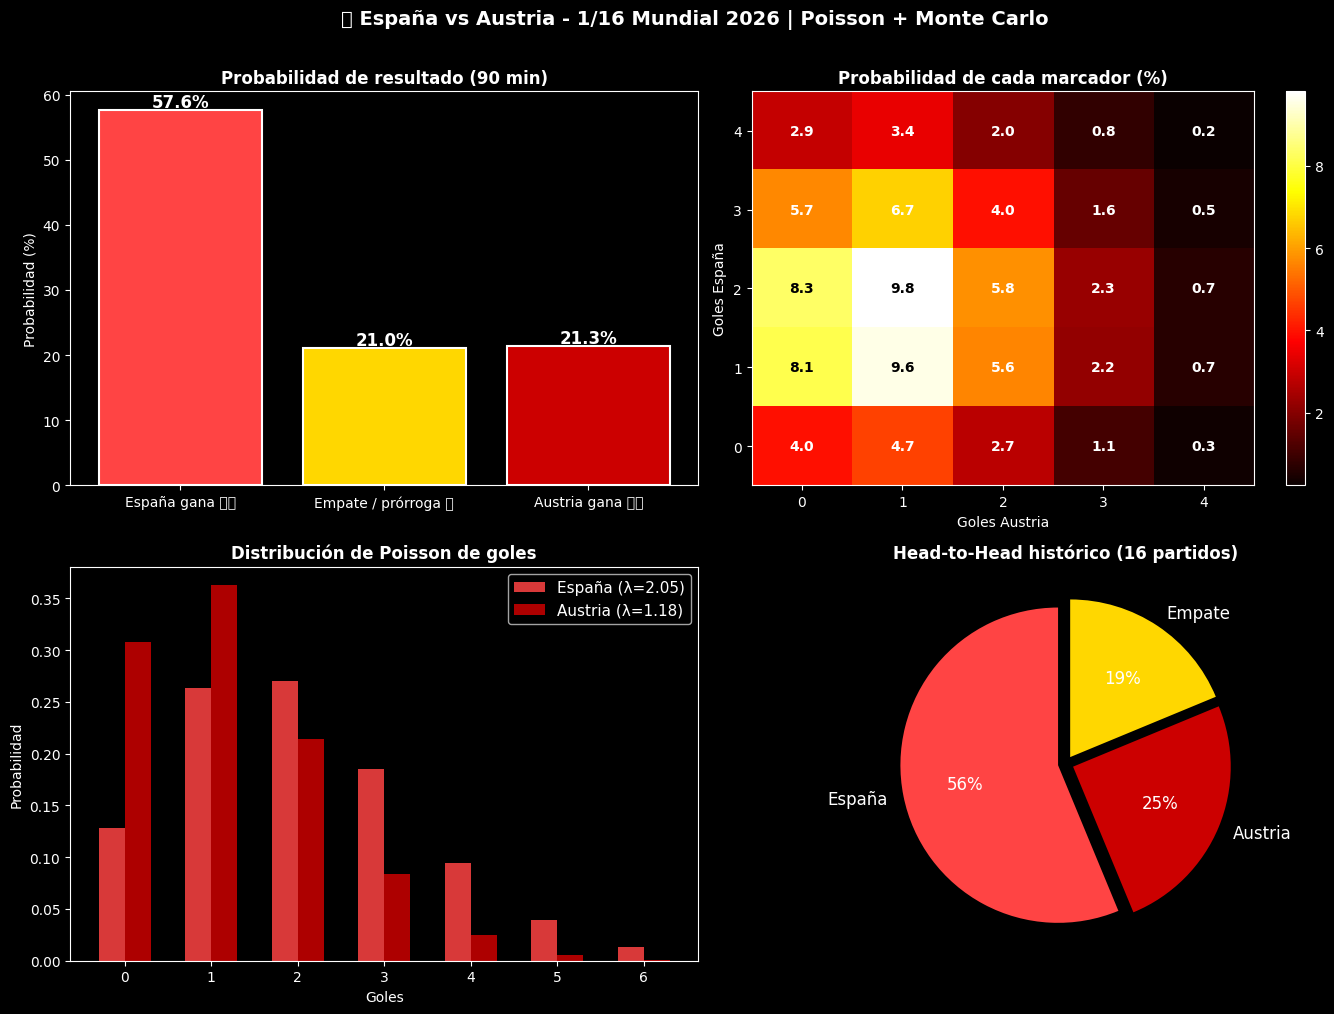

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Probabilidades de resultado
categorias = ['España gana 🇪🇸', 'Empate / prórroga 🤝', 'Austria gana 🇦🇹']
probabilidades = [prob_espana, prob_empate, prob_austria]
colores = ['#FF4444', '#FFD700', '#CC0000']
bars = axes[0,0].bar(categorias, probabilidades, color=colores, edgecolor='white', linewidth=1.5)
axes[0,0].set_ylabel('Probabilidad (%)')
axes[0,0].set_title('Probabilidad de resultado (90 min)', fontweight='bold')
for bar, prob in zip(bars, probabilidades):
    axes[0,0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                   f'{prob:.1f}%', ha='center', fontweight='bold', fontsize=12)

# 2. Heatmap de marcadores
im = axes[0,1].imshow(matriz_prob[:5,:5] * 100, cmap='hot', origin='lower', aspect='auto')
axes[0,1].set_xlabel('Goles Austria')
axes[0,1].set_ylabel('Goles España')
axes[0,1].set_title('Probabilidad de cada marcador (%)', fontweight='bold')
axes[0,1].set_xticks(range(5))
axes[0,1].set_yticks(range(5))
for i in range(5):
    for j in range(5):
        color = 'black' if matriz_prob[i][j] * 100 > 8 else 'white'
        axes[0,1].text(j, i, f'{matriz_prob[i][j]*100:.1f}', ha='center', va='center',
                       fontsize=10, color=color, fontweight='bold')
plt.colorbar(im, ax=axes[0,1])

# 3. Distribución de Poisson de goles
x_vals = np.arange(0, 7)
axes[1,0].bar(x_vals - 0.15, poisson.pmf(x_vals, lambda_spain_final),   0.3,
              color='#FF4444', label=f'España (λ={lambda_spain_final:.2f})', alpha=0.85)
axes[1,0].bar(x_vals + 0.15, poisson.pmf(x_vals, lambda_austria_final), 0.3,
              color='#CC0000', label=f'Austria (λ={lambda_austria_final:.2f})', alpha=0.85)
axes[1,0].set_xlabel('Goles')
axes[1,0].set_ylabel('Probabilidad')
axes[1,0].set_title('Distribución de Poisson de goles', fontweight='bold')
axes[1,0].legend(fontsize=11)
axes[1,0].set_xticks(x_vals)

# 4. H2H histórico pie chart
h2h_counts = h2h['result'].value_counts()
labels_h2h = h2h_counts.index.tolist()
colors_h2h = ['#FF4444' if x=='España' else '#CC0000' if x=='Austria' else '#FFD700' for x in labels_h2h]
axes[1,1].pie(h2h_counts.values, labels=labels_h2h, colors=colors_h2h,
              autopct='%1.0f%%', textprops={'fontsize':12, 'color':'white'},
              startangle=90, explode=[0.05]*len(labels_h2h))
axes[1,1].set_title(f'Head-to-Head histórico ({len(h2h)} partidos)', fontweight='bold')

plt.suptitle('🏆 España vs Austria - 1/16 Mundial 2026 | Poisson + Monte Carlo',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('prediccion_espana_austria.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

## 🧠 Resumen final

In [14]:
prob_esp_total = prob_espana + prob_empate * pen_spain_vs_austria
prob_aut_total = prob_austria + prob_empate * pen_austria_vs_spain

print('╔═══════════════════════════════════════════════════════════════╗')
print('║    🏆 PREDICCIÓN: ESPAÑA vs AUSTRIA - 1/16 MUNDIAL 2026     ║')
print('║    📅 2 julio | SoFi Stadium, Los Ángeles                   ║')
print('╠═══════════════════════════════════════════════════════════════╣')
print(f'║  🇪🇸 Victoria España (90 min):   {prob_espana:>5.1f}%                   ║')
print(f'║  🤝 Empate → prórroga/penaltis: {prob_empate:>5.1f}%                   ║')
print(f'║  🇦🇹 Victoria Austria (90 min):  {prob_austria:>5.1f}%                   ║')
print('╠═══════════════════════════════════════════════════════════════╣')
print(f'║  🎯 Marcador más probable: España {resultados[0][0]}-{resultados[0][1]} Austria          ║')
print('╠═══════════════════════════════════════════════════════════════╣')
print(f'║  🎰 PENALTIS (basado en historial real):                    ║')
print(f'║     España:  {pen_spain["wins"]}W-{pen_spain["losses"]}L ({pen_spain["win_rate"]*100:.0f}%)                              ║')
print(f'║     Austria: {pen_austria["wins"]}W-{pen_austria["losses"]}L ({pen_austria["win_rate"]*100:.0f}%)                              ║')
print('╠═══════════════════════════════════════════════════════════════╣')
print(f'║  📌 PROB. DE PASAR (modelo + penaltis reales):              ║')
print(f'║     España:  {prob_esp_total:.1f}%                                    ║')
print(f'║     Austria: {prob_aut_total:.1f}%                                     ║')
print('╠═══════════════════════════════════════════════════════════════╣')
print(f'║  📊 DATOS:                                                  ║')
print(f'║  • {len(df):,} partidos analizados                             ║')
print(f'║  • {len(h2h)} enfrentamientos directos España-Austria             ║')
print(f'║  • {len(shootouts)} tandas de penaltis en el dataset                ║')
print('╚═══════════════════════════════════════════════════════════════╝')
print()
print('⚠️  Modelo estadístico. En eliminatoria, un gol lo cambia todo.')
print('📱 @r2d2.coder')

╔═══════════════════════════════════════════════════════════════╗
║    🏆 PREDICCIÓN: ESPAÑA vs AUSTRIA - 1/16 MUNDIAL 2026     ║
║    📅 2 julio | SoFi Stadium, Los Ángeles                   ║
╠═══════════════════════════════════════════════════════════════╣
║  🇪🇸 Victoria España (90 min):    57.6%                   ║
║  🤝 Empate → prórroga/penaltis:  21.0%                   ║
║  🇦🇹 Victoria Austria (90 min):   21.3%                   ║
╠═══════════════════════════════════════════════════════════════╣
║  🎯 Marcador más probable: España 2-1 Austria          ║
╠═══════════════════════════════════════════════════════════════╣
║  🎰 PENALTIS (basado en historial real):                    ║
║     España:  7W-7L (50%)                              ║
║     Austria: 0W-2L (0%)                              ║
╠═══════════════════════════════════════════════════════════════╣
║  📌 PROB. DE PASAR (modelo + penaltis reales):              ║
║     España:  78.7%                                    ║
║    